In [1]:
from pathlib import Path
from src import config
import cv2
import numpy as np
from src.court_detector import CourtDetector
from src.utils.helpers import crop_center_img, load_process_params
from src.config import set_debug_mode, get_debug_mode
from cvgeomkit.utils.helpers import read_image_as_numpyimage, load_json
from cvgeomkit.utils.plotting import display_img

In [2]:
get_debug_mode()
set_debug_mode(True)

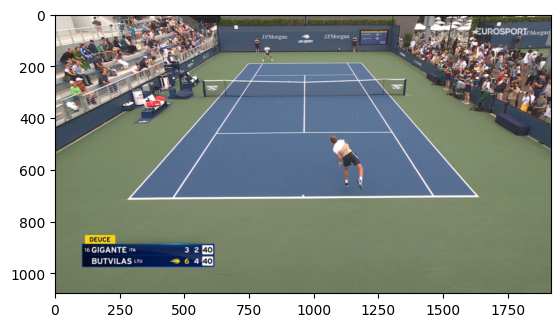

In [3]:
path = '../data/pics/04_23.png'
# path = '../data/pics/skip/skip_01_35.png'
img = read_image_as_numpyimage(path)
display_img(img)

In [4]:
params =load_process_params('../config/process_params.config.json')


service_side = params.match_params.service_side.value
match_type = params.match_params.match_type.value

roi_h = params.detection_params.traversing.roi_height_px
step = params.detection_params.traversing.step_px
warmup = params.detection_params.traversing.warmup

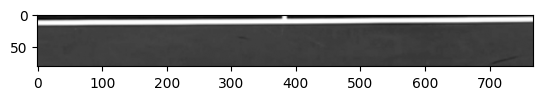

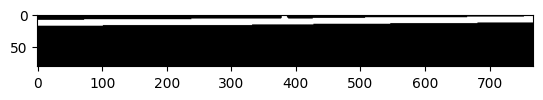

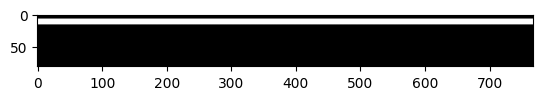

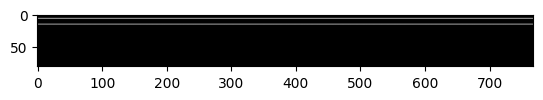

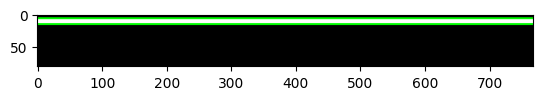

service_line_candidates ---
[y = 0.0 * x + 6.0, y = 0.0 * x + 15.0]
centre_service_line_candidates before ---
None


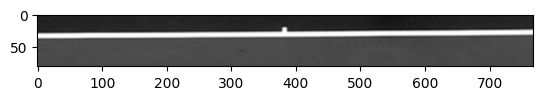

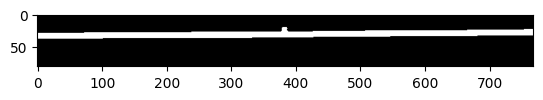

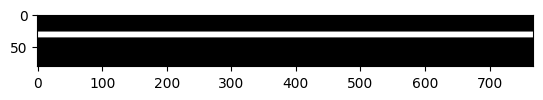

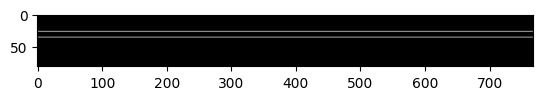

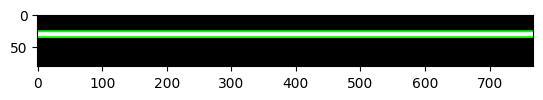

service_line_candidates ---
[y = 0.0 * x + 26.0, y = 0.0 * x + 35.0]
centre_service_line_candidates before ---
None


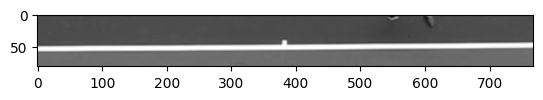

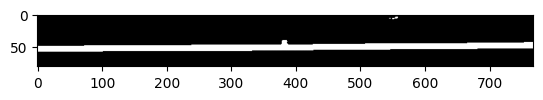

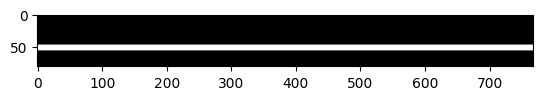

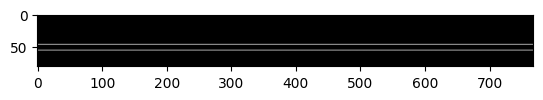

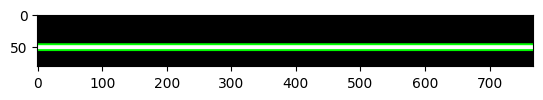

service_line_candidates ---
[y = 0.0 * x + 46.0, y = 0.0 * x + 55.0]
centre_service_line_candidates before ---
None


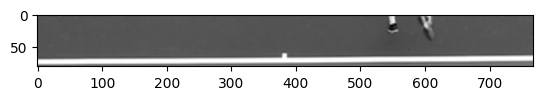

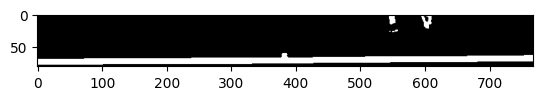

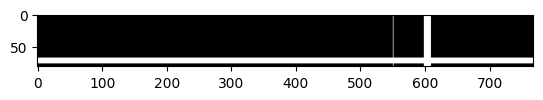

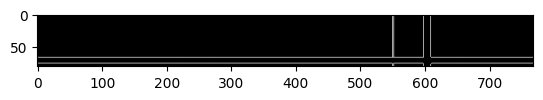

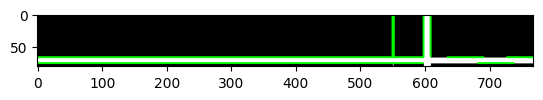

service_line_candidates ---
[y = 0.0 * x + 66.0, y = 0.0 * x + 75.0, y = 0.0 * x + 66.0, y = 0.0 * x + 75.0, y = 0.0 * x + 66.0]
centre_service_line_candidates before ---
[y = None * x + None, y = None * x + None, y = None * x + None, y = None * x + None]
centre_service_line_candidates after ---
[]


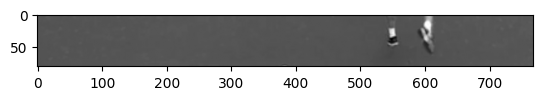

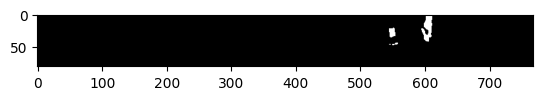

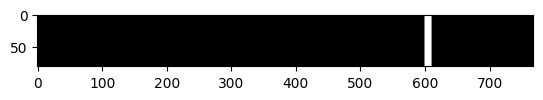

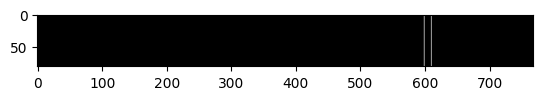

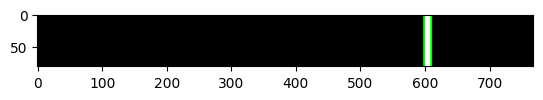

service_line_candidates ---
None


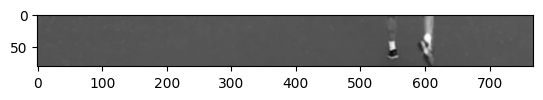

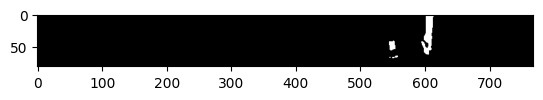

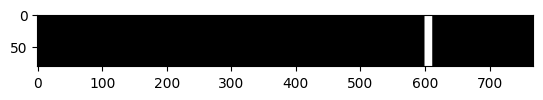

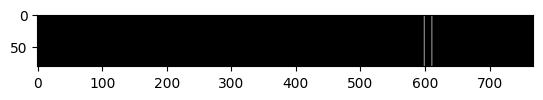

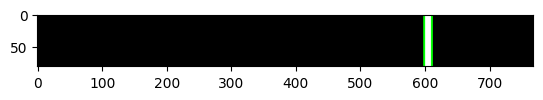

service_line_candidates ---
None


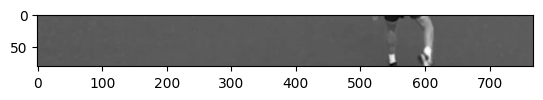

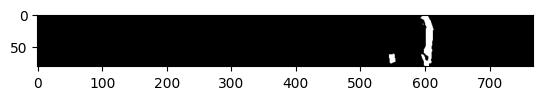

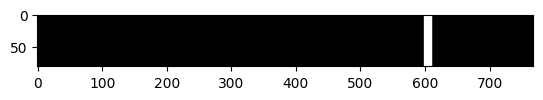

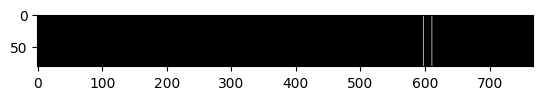

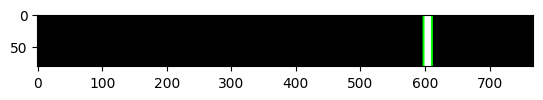

service_line_candidates ---
None


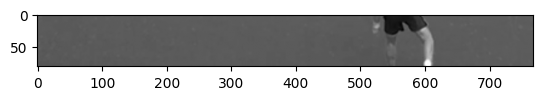

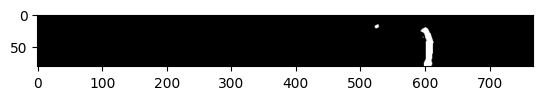

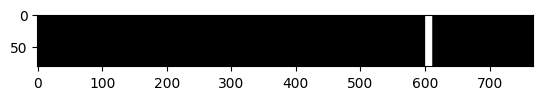

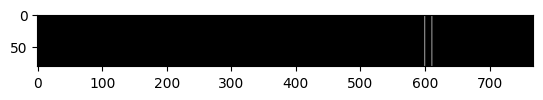

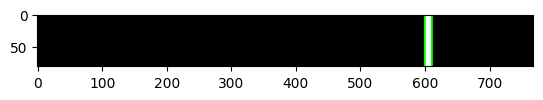

service_line_candidates ---
None


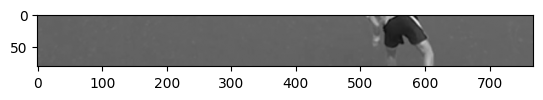

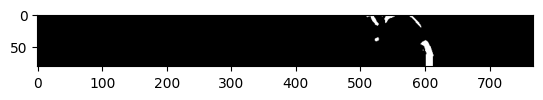

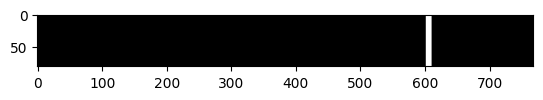

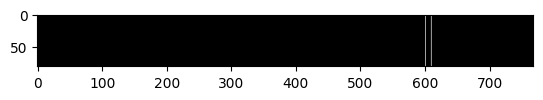

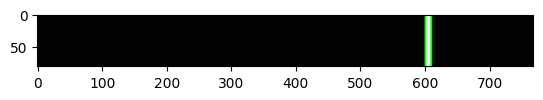

service_line_candidates ---
None


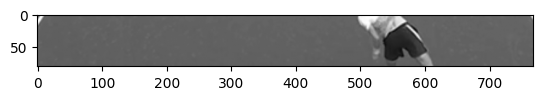

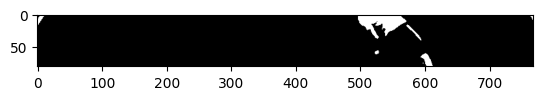

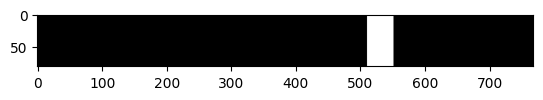

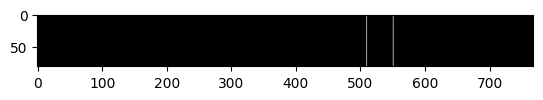

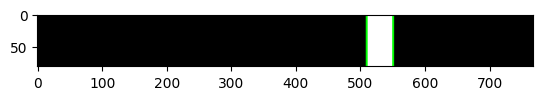

service_line_candidates ---
None


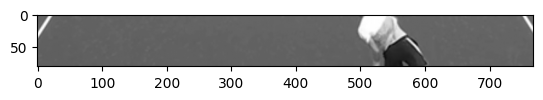

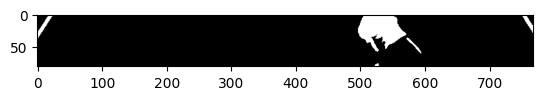

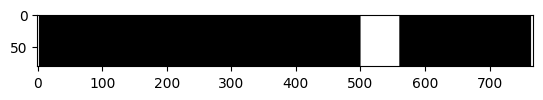

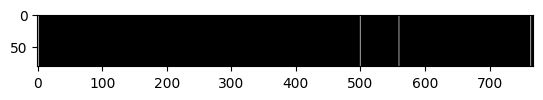

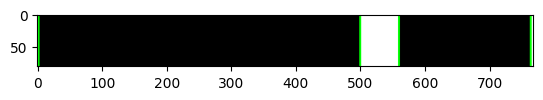

service_line_candidates ---
None


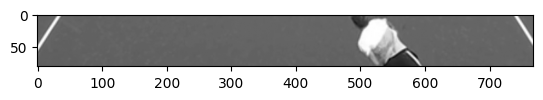

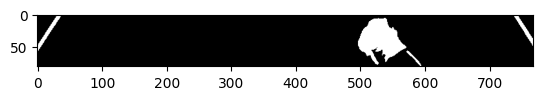

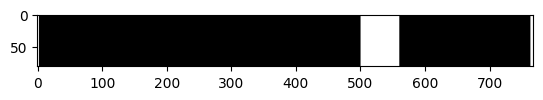

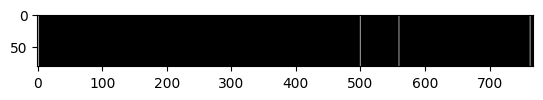

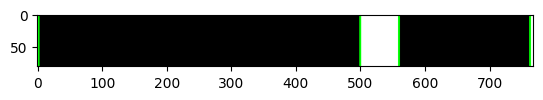

service_line_candidates ---
None


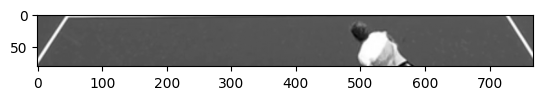

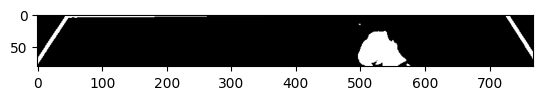

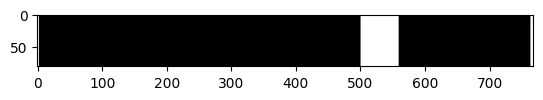

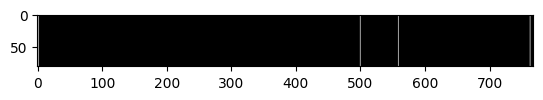

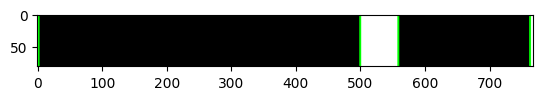

service_line_candidates ---
[y = 0.0 * x + 1.0, y = 0.0 * x + 1.0, y = 0.0 * x + 1.0]
centre_service_line_candidates before ---
[y = None * x + None, y = None * x + None, y = None * x + None, y = None * x + None]
centre_service_line_candidates after ---
[]


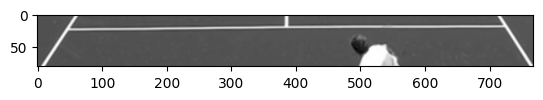

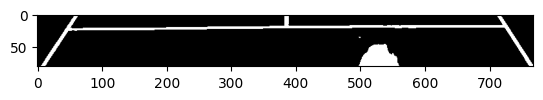

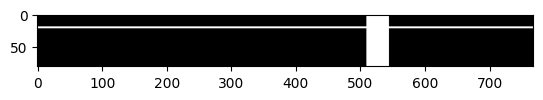

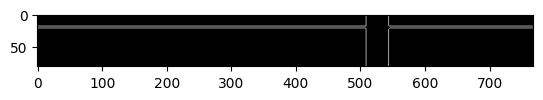

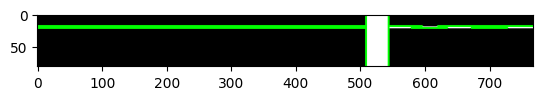

service_line_candidates ---
[y = 0.0 * x + 18.0, y = 0.0 * x + 21.0, y = 0.0 * x + 18.0, y = 0.0 * x + 18.0, y = 0.0 * x + 18.0, y = 0.0 * x + 18.0, y = 0.0 * x + 21.0, y = 0.0 * x + 21.0]
centre_service_line_candidates before ---
[y = None * x + None, y = None * x + None]
centre_service_line_candidates after ---
[]


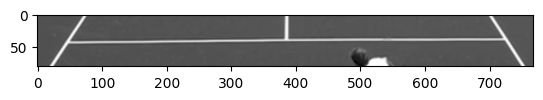

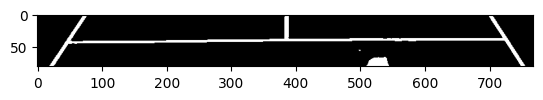

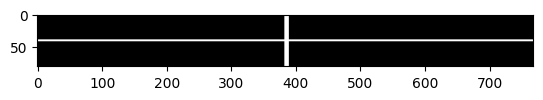

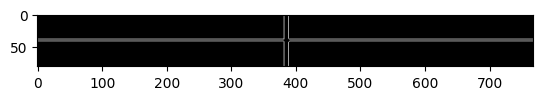

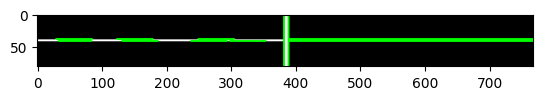

service_line_candidates ---
[y = 0.0 * x + 38.0, y = 0.0 * x + 41.0, y = 0.0 * x + 38.0, y = 0.0 * x + 41.0, y = 0.0 * x + 38.0, y = 0.0 * x + 38.0, y = 0.0 * x + 41.0, y = 0.0 * x + 41.0, y = 0.0 * x + 41.0]
centre_service_line_candidates before ---
[y = None * x + None, y = None * x + None]
centre_service_line_candidates after ---
[y = None * x + None, y = None * x + None]
intersections
{Point (389, 38) line1: [y = 0.00 * x + 38.00] line2: [x = 389.00], Point (382, 38) line1: [y = 0.00 * x + 38.00] line2: [x = 382.00], Point (389, 41) line1: [y = 0.00 * x + 41.00] line2: [x = 389.00], Point (382, 41) line1: [y = 0.00 * x + 41.00] line2: [x = 382.00]}
filtered intersections
(y = 0.0 * x + 41.0, y = None * x + None, Point(389, 41))
intersections ---
{Point (389, 38) line1: [y = 0.00 * x + 38.00] line2: [x = 389.00], Point (382, 38) line1: [y = 0.00 * x + 38.00] line2: [x = 382.00], Point (389, 41) line1: [y = 0.00 * x + 41.00] line2: [x = 389.00], Point (382, 41) line1: [y = 0.00 * x +

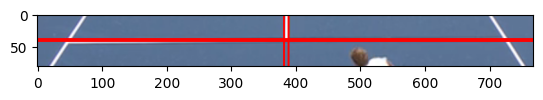

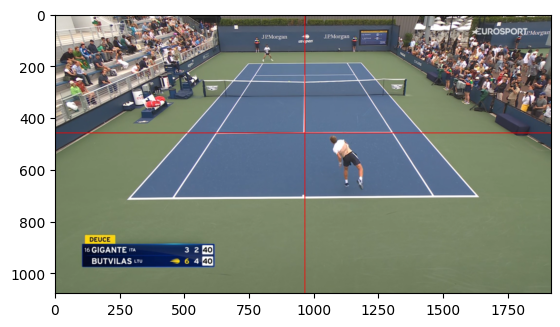

In [5]:
detector = CourtDetector(img)

centre_intresection = detector.scan_for_service_lines(service_side, roi_h, step, warmup)

if centre_intresection is not None:
    service_line, centre_service_line, service_point = centre_intresection

    p1, p2 = service_line.limit_to_img(img)
    p3, p4 = centre_service_line.limit_to_img(img)

    img_copy = img.copy()
    cv2.line(img_copy, p1, p2, (255, 0, 0), 2)
    cv2.line(img_copy, p3, p4, (255, 0, 0), 2)

    display_img(img_copy)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
i:  15


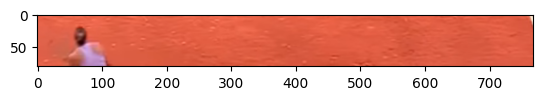

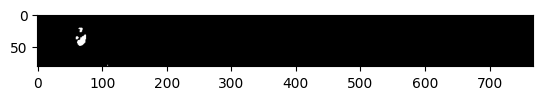

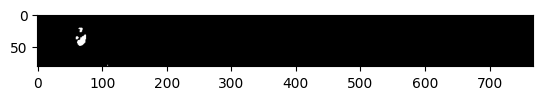

15
i:  16


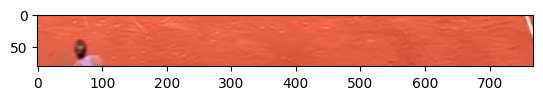

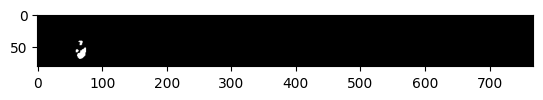

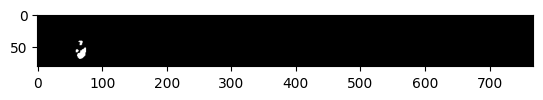

16
i:  17


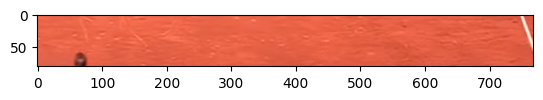

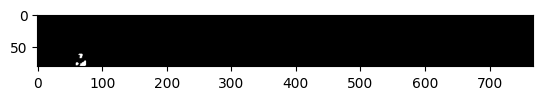

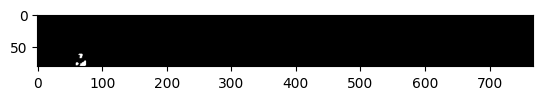

17
i:  18


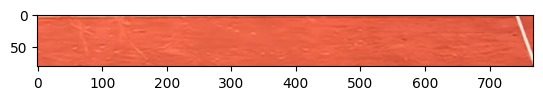

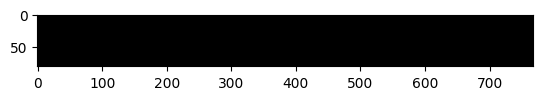

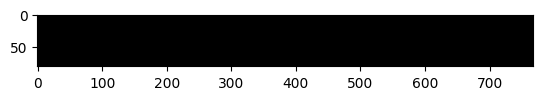

18
i:  19


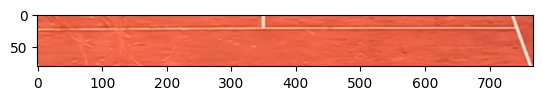

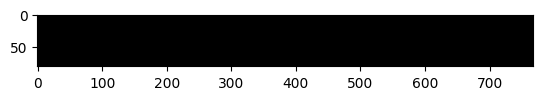

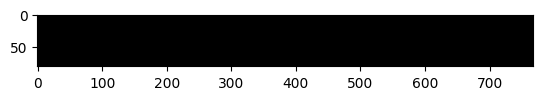

19
i:  20


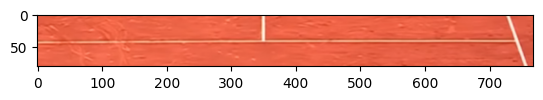

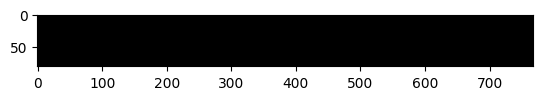

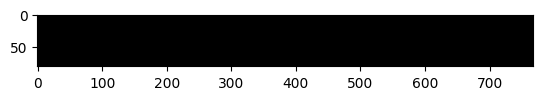

20
i:  21


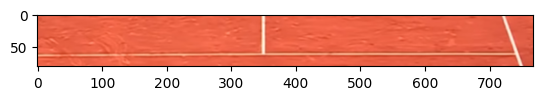

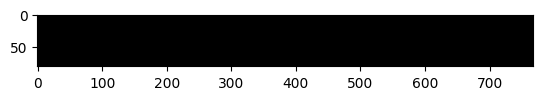

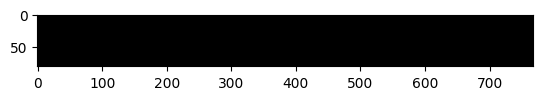

21
i:  22


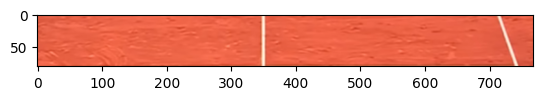

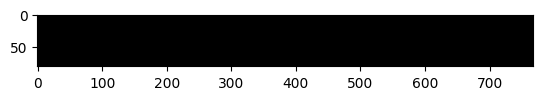

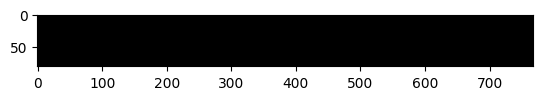

22
i:  23


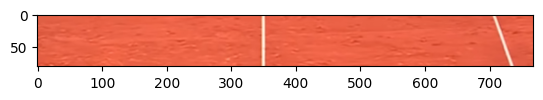

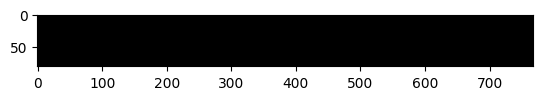

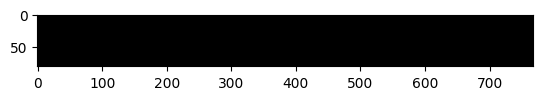

23
i:  24


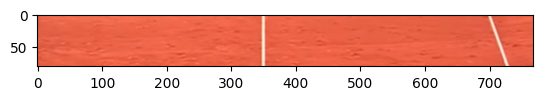

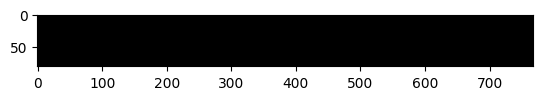

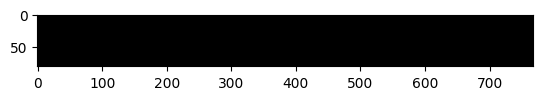

24
i:  25


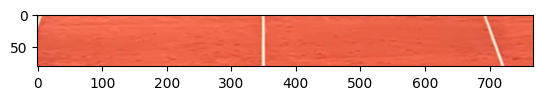

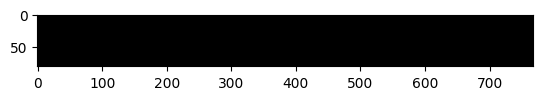

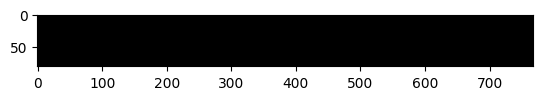

25
i:  26


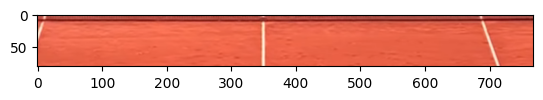

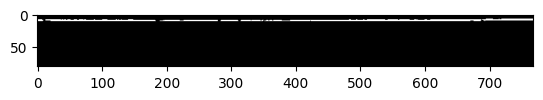

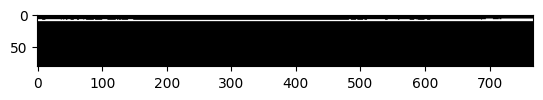

26
i:  27


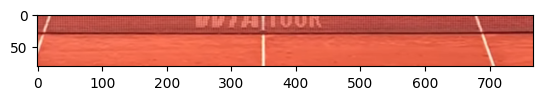

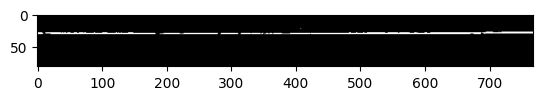

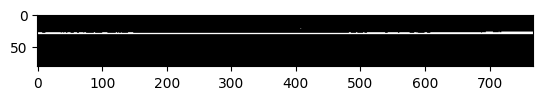

27
i:  28


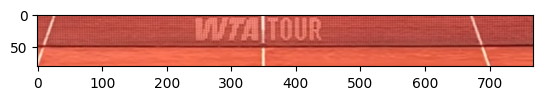

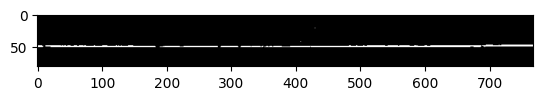

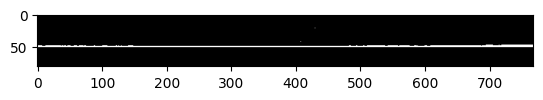

28
i:  29


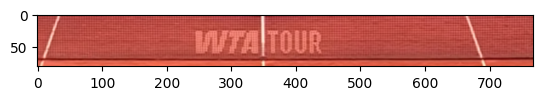

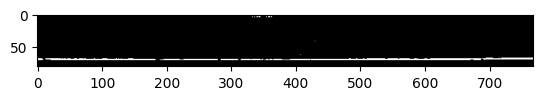

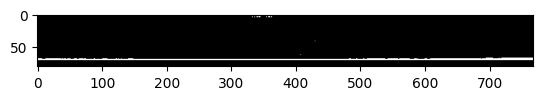

29
i:  30


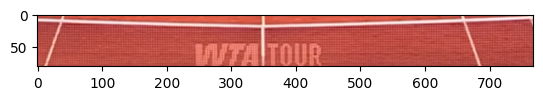

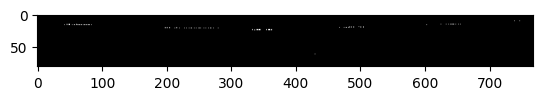

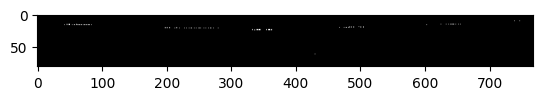

30
i:  31


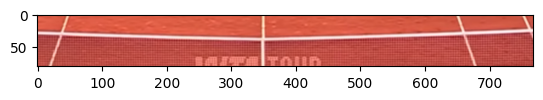

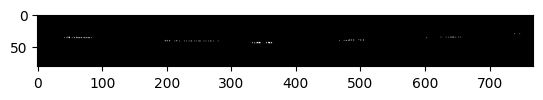

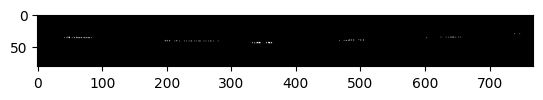

31
i:  32


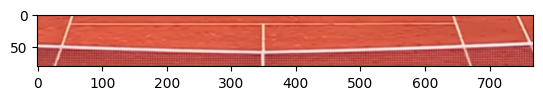

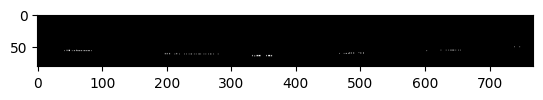

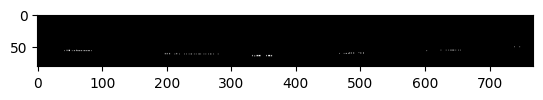

32
i:  33


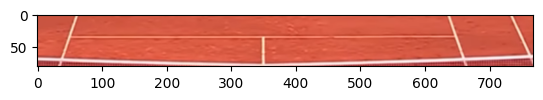

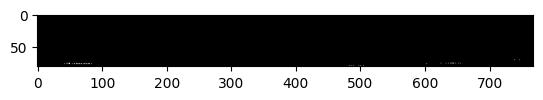

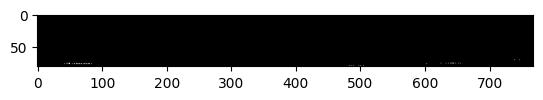

33
i:  34


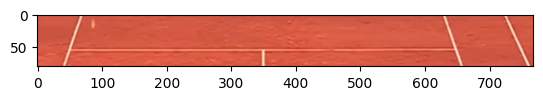

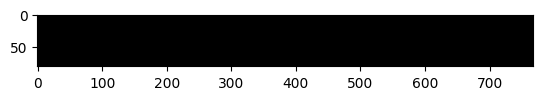

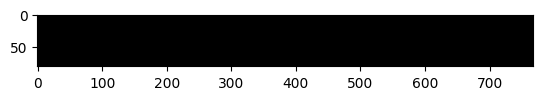

34
i:  35


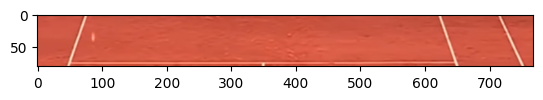

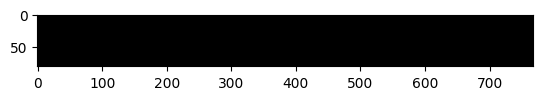

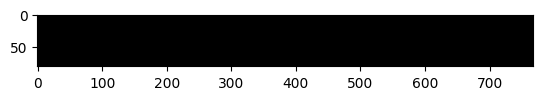

35
i:  36


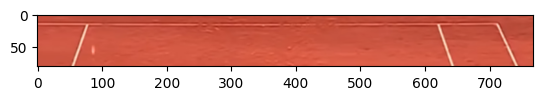

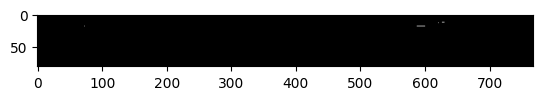

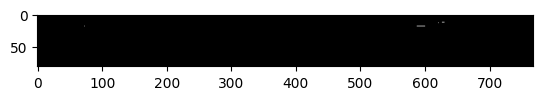

36
i:  37


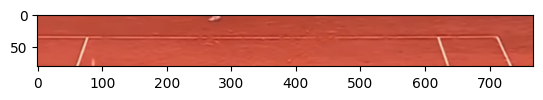

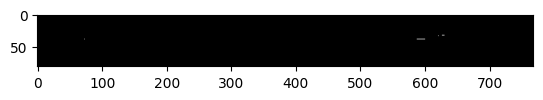

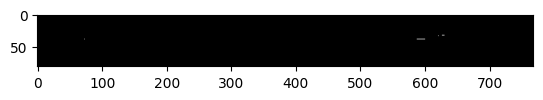

37
i:  38


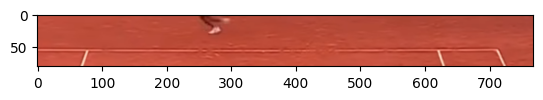

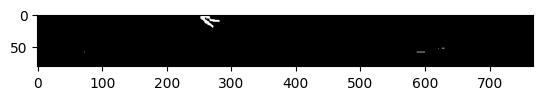

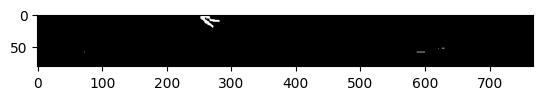

38
i:  39


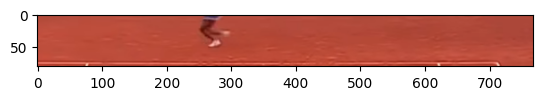

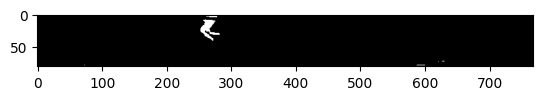

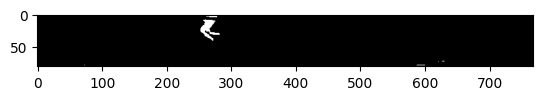

39
i:  40


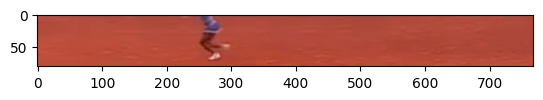

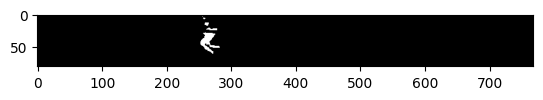

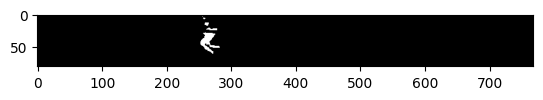

40
i:  41


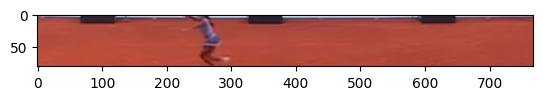

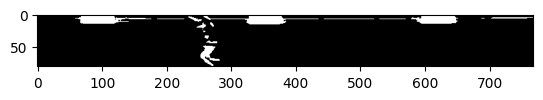

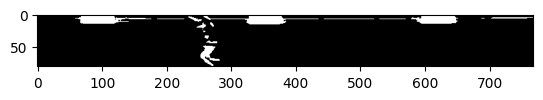

41
i:  42


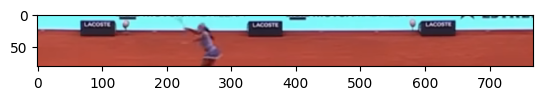

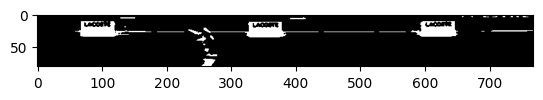

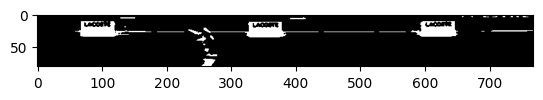

42
i:  43


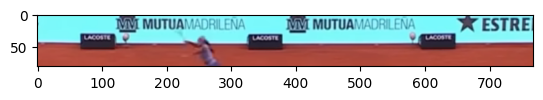

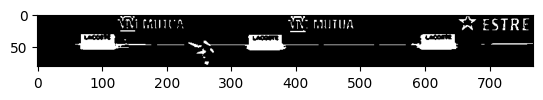

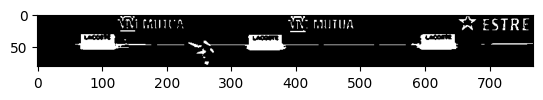

43
i:  44


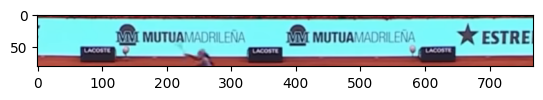

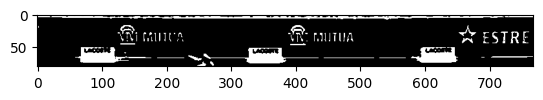

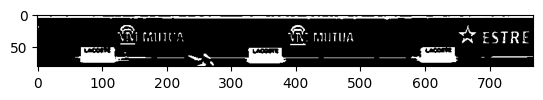

44
i:  45


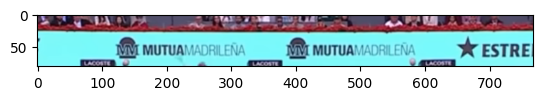

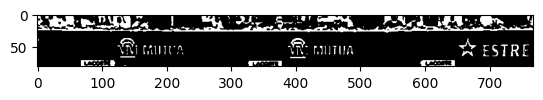

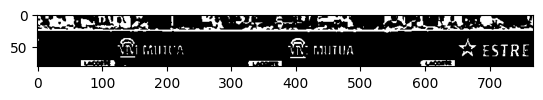

45
i:  46


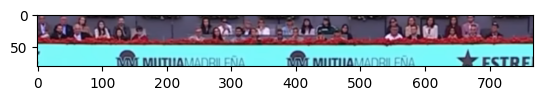

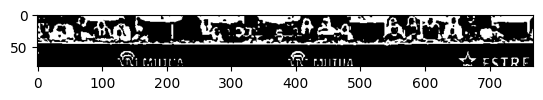

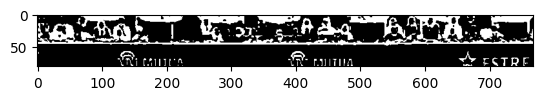

46
i:  47


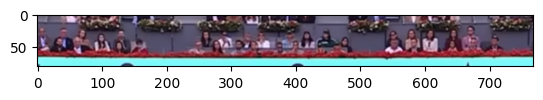

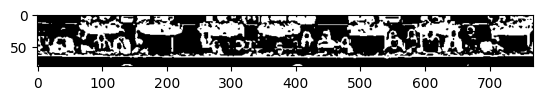

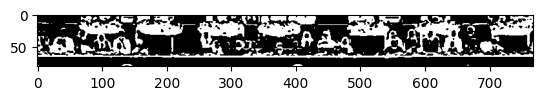

47
i:  48


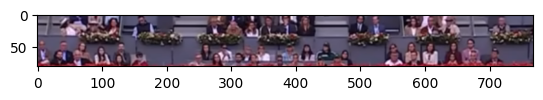

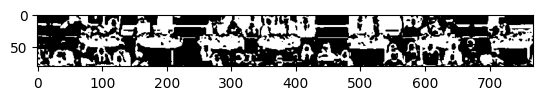

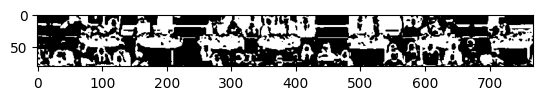

48
i:  49


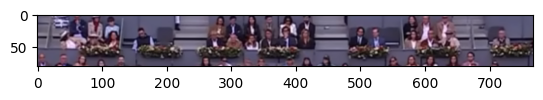

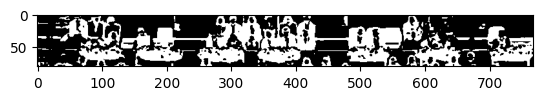

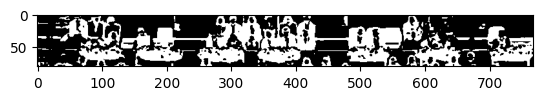

49
i:  50


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/core/src/arithm.cpp:2048: error: (-215:Assertion failed) ! _src.empty() in function 'inRange'


In [ ]:
pics_dir = Path('../data/pics')

for pic in pics_dir.glob('*.png'):

    img = read_image_as_numpyimage(pic)

    detector = CourtDetector(img)

    detector.scan_for_net_line(roi_h, step, warmup)



    break


